# Wybory Prezydenckie 2025 (I Tura) – Radykalna Kartografia
---

Witaj na kolejnych zajęciach z wizualizacji danych! Dzisiaj połączymy twarde dane polityczne (wyniki I tury wyborów prezydenckich z PKW) z mapami przestrzennymi w pakiecie **Geopandas**.

Naszym przewodnikiem będzie William Rankin i jego książka **„Radical Cartography: How Changing Our Maps Can Change Our World”**. Autor zauważa, że tradycyjne mapy wyborcze to najwięksi kłamcy współczesnej kartografii.

Cierpią one na tzw. **Pułapkę Jurysdykcyjną (Jurisdictional Trap)**. Zamalowują całe powiaty jednym kolorem (*jigsaw-puzzle maps*), zmuszając nas do myślenia, że wielkie, zalesione i słabo zaludnione terytoria mają takie samo znaczenie jak gęsto zaludnione miasta. Tworzą też fałszywy, ostry podział na "Polskę A i Polskę B". Ziemia jednak nie głosuje – głosują ludzie!

**Podczas tych zajęć nauczymy się:**
1. Wczytywać i czyścić rzeczywiste dane wyborcze z PKW (naprawiając kody TERYT).
2. Tworzyć zaawansowaną galerię **Small Multiples** używając `plt.subplot_mosaic()`.
3. Agregować dane ideologicznie (Lewica, Centrum, Prawica).
4. Dekonstruować mapy (Makeover): przejdziemy od mylących kartogramów do map bąbelkowych (Bubble Maps), które niszczą iluzję terytorialną.

## Zadanie 1: Pobieranie i agregacja danych z I Tury, naprawa TERYT i Merge
---

Dzisiaj będziemy pracować na "twardych" plikach prosto od polskich instytucji państwowych. Zanim zaczniesz kodować, musisz zdobyć dane i wgrać je do wirtualnej pamięci Google Colab (ikona folderu po lewej stronie).

1. **Wyniki Wyborów (PKW):** Pobierz plik `wyniki_gl_na_kandydatow_po_powiatach_utf8.csv` ze strony: `https://prezydent2025.pkw.gov.pl/prezydent2025/pl/dane_w_arkuszach` (zakładka pierwsza tura). Wgraj plik do Colaba.
2. **Mapa Polski (GUGiK - CAPAP):** Wejdź na stronę `https://capap.gugik.gov.pl/cat/org/gugik/dane/jednostki-administracyjne-f5cnk`. Zjedź w dół do sekcji "Pobierz", kliknij w przycisk obok formatu **GeoJSON**. Zapisz ten duży plik na dysku i wgraj do środowiska Colaba. Nazwa wgranego pliku powinna wyglądać mniej więcej tak: `typ-podpowiedz-nazwa-teryt-parentid-geojson.geojson`.

Pojawia się tu klasyczny problem analityczny. W plikach CSV od PKW kody TERYT często gubią wiodące zera, wczytują się jako liczby ułamkowe (np. `20100.0` zamiast `020100`) i mają zbędne zera na końcu. Z kolei pobrana przed chwilą mapa od GUGiK to nie mapa powiatów, a **mapa wszystkich gmin w Polsce**! Jej TERYT ma 7 znaków. Musimy to wyczyścić, uciąć do pierwszych 4 znaków (powiaty) i scalić przestrzennie małe gminy w wielkie powiaty.

**Co musisz wiedzieć o funkcjach w tym zadaniu:**
* `df.dropna(subset=['Województwo'])` – usuwa wiersze podsumowujące dla statków i zagranicy (ich nie narysujemy na mapie PL).
* `df['kol'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6).str[:4]` – magiczna sekwencja naprawcza PKW: zamienia na tekst, usuwa to, co po kropce, dodaje zera z przodu do sześciu znaków, po czym odcina tylko pierwsze 4 znaki (kod powiatu).
* `gdf.dissolve(by='kolumna')` – to przestrzenny odpowiednik `groupby()`. Połączy ze sobą (sklei geometrię) wszystkie małe gminy, które mają ten sam 4-cyfrowy kod powiatu.

**Instrukcja krok po kroku:**
1. Zaimportuj biblioteki: `pandas as pd`, `geopandas as gpd`, `matplotlib.pyplot as plt`. Ustaw `plt.style.use('default')`.
2. Wczytaj plik z PKW do zmiennej `df_wybory` (użyj `sep=';'`).
3. Oczyść dane: usuń wiersze, gdzie kolumna `'Województwo'` jest pusta (`NaN`) przy użyciu metody opisanej wyżej.
4. **Napraw kod TERYT w danych PKW:** Stwórz nową kolumnę `'TERYT_clean'` stosując wyżej opisaną sekwencję (replace, zfill, ucinanie) na kolumnie `'TERYT Powiatu'`.
5. Przygotuj listę nazwisk 13 kandydatów (zaczynają się od "BARTOSZEWICZ Artur", a kończą na "ZANDBERG Adrian Tadeusz"). Wyciągnij je podając numery kolumn: `kandydaci = df_wybory.columns[28:41].tolist()`.
6. Stwórz pętlę iterującą po tej liście. Dla każdego kandydata stwórz nową kolumnę (np. `f"{kandydat}_%"`). Wynik to: głosy na niego podzelone przez `'Liczba głosów ważnych oddanych łącznie na wszystkich kandydatów'`, a na koniec pomnożone przez 100.
7. Wczytaj wgraną wcześniej z GUGiK mapę gmin do zmiennej `gdf`. Podaj dokładną nazwę pliku `.geojson`, który przed chwilą wgrałeś do wirtualnego folderu Colaba (uwaga, ten duży plik wczytuje się przez dłuższą chwilę!).
8. **Agregacja przestrzenna (Dissolve):**
   * Wyciągnij 4 pierwsze znaki z kolumny `'teryt'` w pliku mapy i zapisz do nowej: `gdf['teryt_powiatu'] = gdf['teryt'].str[:4]`. To będzie nasz klucz powiatowy.
   * Teraz sklej granice gmin, by stworzyć piękne, czyste powiaty wywołując na mapie funkcję `.dissolve()`. Argumentem `by` niech będzie Twoja nowa kolumna `'teryt_powiatu'`. Wynik natychmiast potraktuj metodą `.reset_index()` i nadpisz pod nazwą `gdf_powiaty`.
9. **Merge:** Mamy teraz przygotowaną mapę idealnych, "zlepionych" przestrzennie powiatów! Połącz `gdf_powiaty` z bazą PKW `df_wybory`. Klucz lewy (`left_on`) to `'teryt_powiatu'`, a klucz prawy (`right_on`) to `'TERYT_clean'`. Wynik zapisz do ostatecznej zmiennej `gdf_merged`. Wydrukuj nagłówek z imieniem kandydata, by sprawdzić połączenie.

In [17]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
df_wybory = pd.read_csv('wyniki_gl_na_kandydatow_po_powiatach_utf8.csv', sep=';')
df_wybory = df_wybory.dropna(subset=['Województwo'])
df_wybory['TERYT_clean'] = df_wybory['TERYT Powiatu'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6).str[:4]
kandydaci = df_wybory.columns[28:41].tolist()

for kandydat in kandydaci:
    df_wybory[f"{kandydat}_%"] = (df_wybory[kandydat] / df_wybory['Liczba głosów ważnych oddanych łącznie na wszystkich kandydatów']) * 100

gdf = gpd.read_file('typ-podpowiedz-nazwa-teryt-parentid-geojson.geojson')
gdf['teryt_powiatu'] = gdf['teryt'].str[:4]

gdf_powiaty = gdf.dissolve(by='teryt_powiatu').reset_index()
gdf_merged = gdf_powiaty.merge(df_wybory, left_on='teryt_powiatu', right_on='TERYT_clean')

gdf_merged[[f"{kandydaci[12]}_%"]].head()
#gdf_merged.head()

,ZANDBERG Adrian Tadeusz_%
0,3.741053
1,3.540006
2,4.248477
3,3.828462
4,3.635784


## Zadanie 2: Galeria Poparcia – Small Multiples z własną skalą
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 7 "Time", s. 283-284 - Edward Tufte's Small Multiples).*

Zbudujemy galerię map pokazujących poparcie dla kandydatów. Aby nasze porównania były uczciwe, każda mapa otrzyma własny pasek skali (`colorbar`). Dzięki `plt.subplot_mosaic()` możemy stworzyć zaawansowany układ wykresów, gdzie liderzy zajmują więcej miejsca, a pozostali kandydaci są w mniejszym formacie.

**Wskazówki techniczne:**
* `plt.subplot_mosaic(layout)` – przyjmuje stringa, gdzie litery to osie, a kropki `.` to puste przestrzenie.
* `legend=True` wewnątrz `.plot()` – automatycznie dodaje pasek kolorów, ale wymaga ustawienia `legend_kwds`.
* **Sugerowane kolory (cmap):**
    * Trzaskowski (Centrum): `'Oranges'`
    * Nawrocki (Prawica): `'Blues'`
    * Mentzen (Prawica): `'PuBu'`
    * Hołownia (Centrum): `'Wistia'`
    * Biejat (Lewica): `'Reds'`

**Instrukcja krok po kroku:**
1. Stwórz strukturę mozaiki: `layout = """ AABB \n CDEF \n GHIJ \n KLM. """`.
2. Posortuj kandydatów malejąco według ich średniego poparcia w Polsce.
3. Wywołaj `fig, axes_dict = plt.subplot_mosaic(layout, figsize=(20, 16))`.
4. Użyj pętli `for litera, ax in axes_dict.items():` aby wypełnić każdą komórkę:
   * **Pominięcie:** Jeśli `litera == '.'`, wywołaj `ax.axis('off')` i użyj `continue`.
   * **Wybór kandydata:** Pobierz nazwisko z Twojego słownika mapującego literę na kandydata.
   * **Dynamiczne skalowanie:** Wylicz `vmax = gdf_merged[f"{kandydat}_%"].max()`. To zapewni, że najjaśniejszy kolor na mapie to 0, a najciemniejszy to najlepszy wynik tego konkretnego kandydata.
   * **Rysowanie:** Wywołaj `gdf_merged.plot(...)`. Argumenty:
      * `column=f"{kandydat}_%"`
      * `cmap='Blues'` (dla Nawrockiego) lub odpowiednia paleta (zdefiniuj i użyj słownika `cmaps` w kodzie).
      * `vmin=0`, `vmax=vmax` (użyj wyliczonego przed chwilą `vmax`).
      * `legend=True`, `legend_kwds={'shrink': 0.5}`.
      * `edgecolor='gray'`, `linewidth=0.1` (bardzo cienkie granice, żeby nie przytłaczały mapy).
   * **Czyszczenie:** `ax.axis('off')` i dodaj tytuł `ax.set_title(...)`.

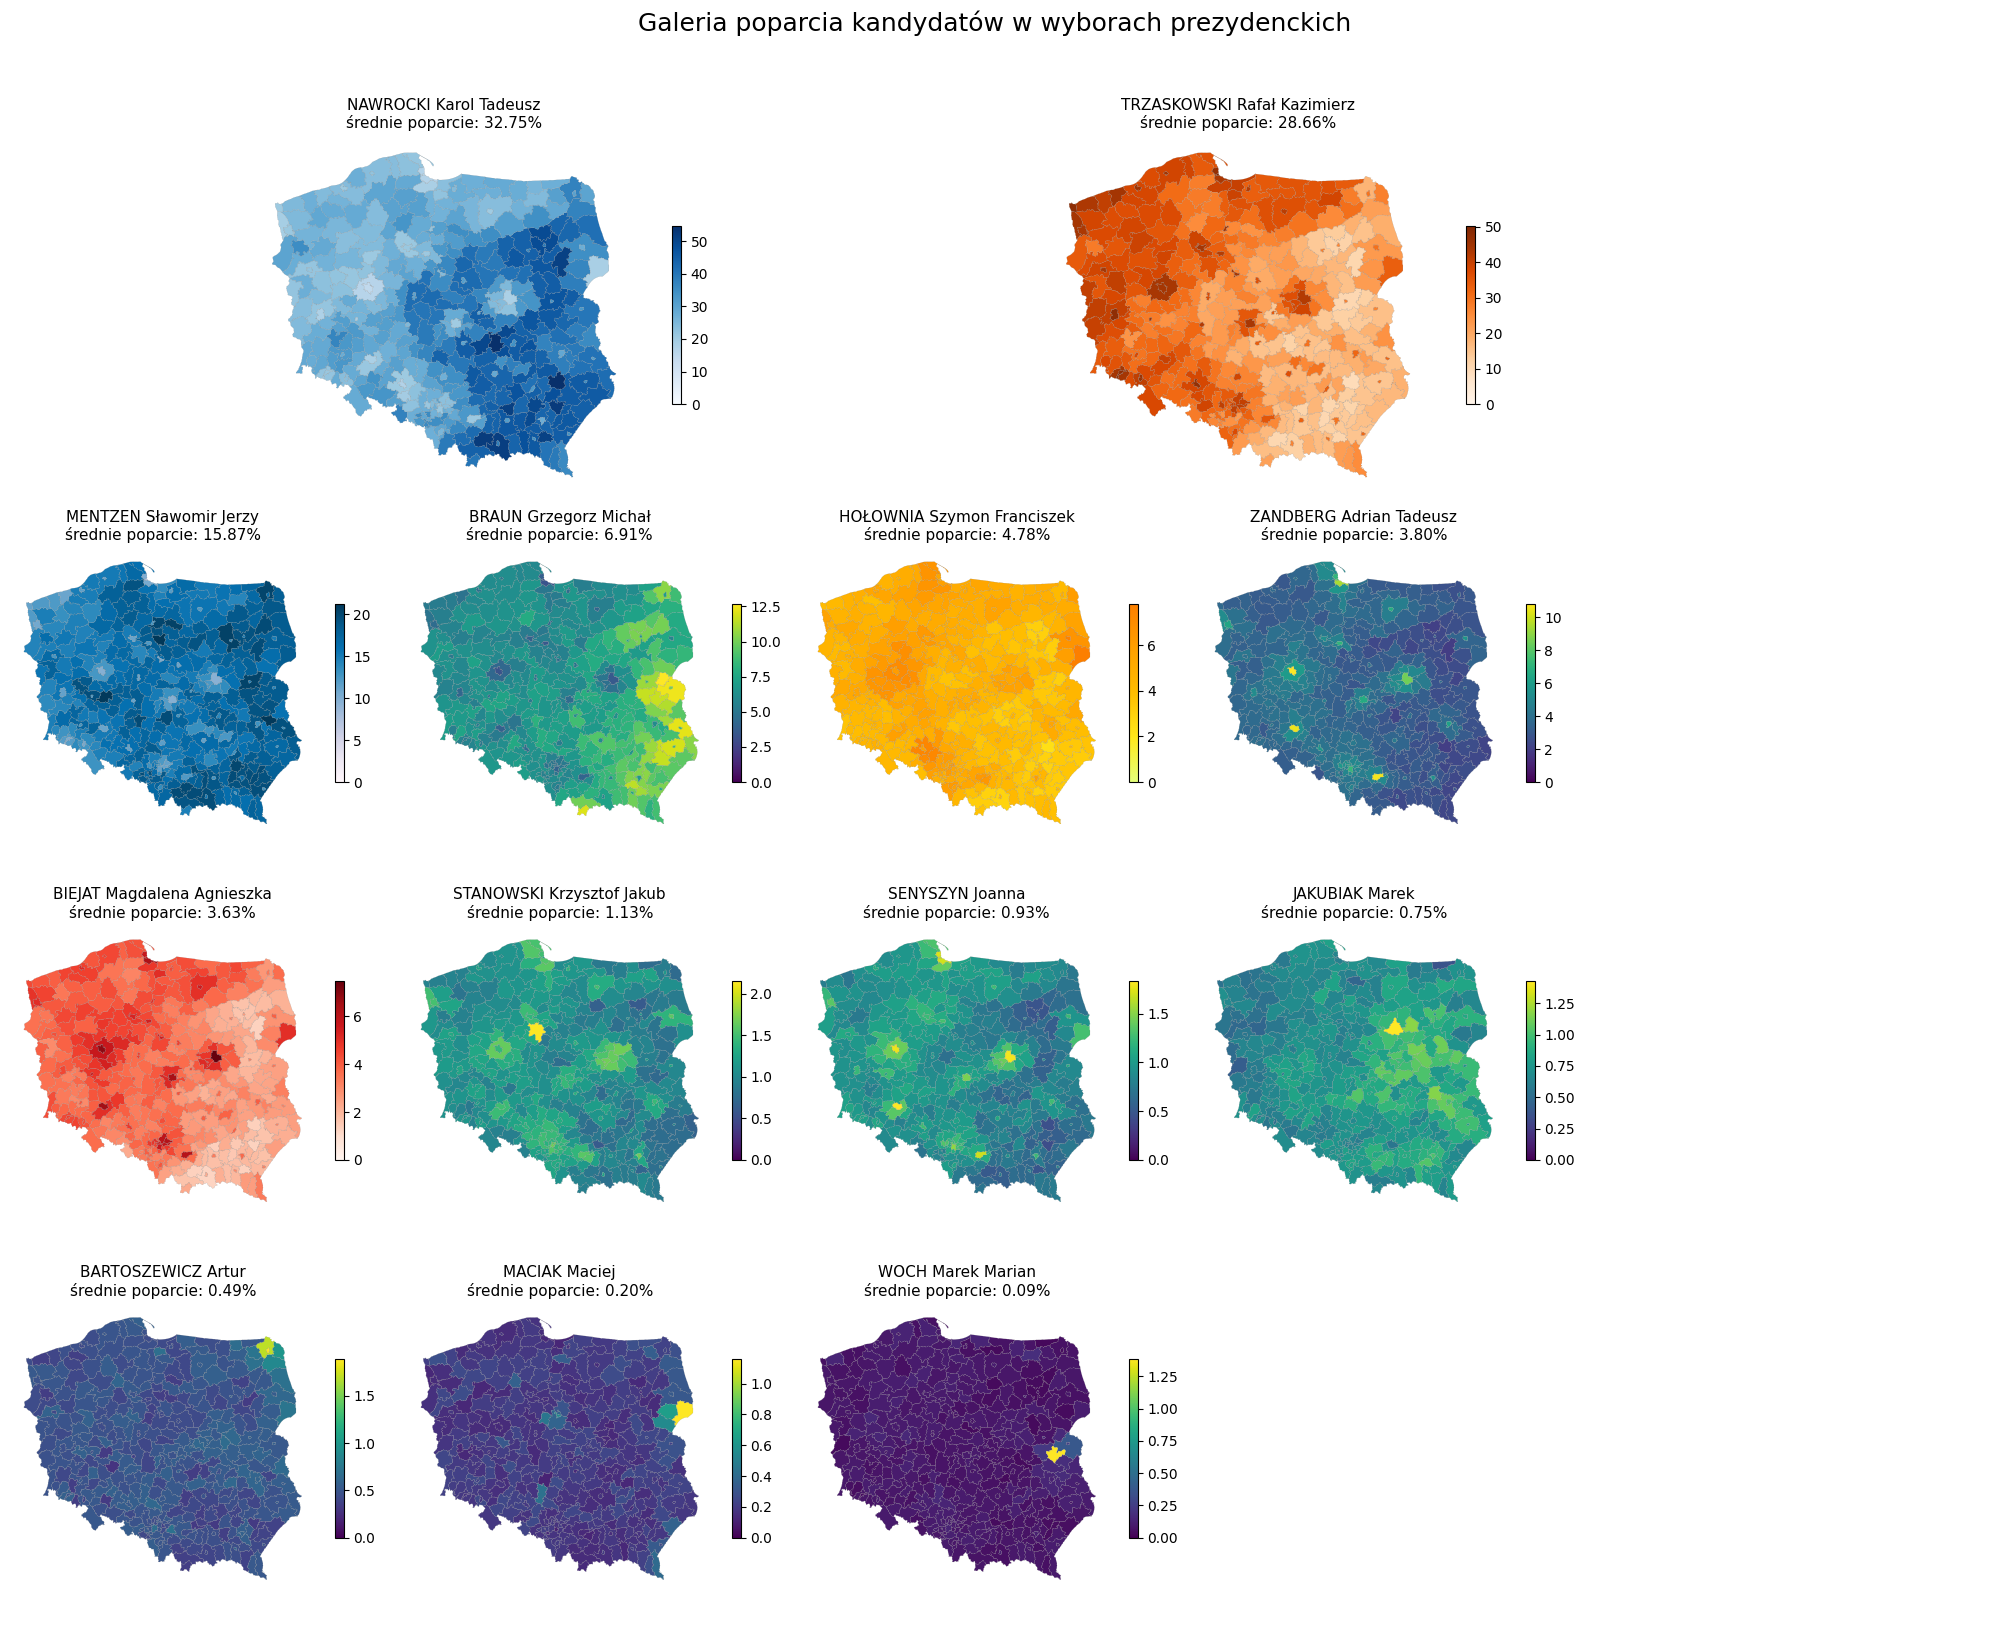

In [18]:
layout = """ AABB \n CDEF \n GHIJ \n KLM. """

sorted_kandydaci = (gdf_merged[[f"{k}_%" for k in kandydaci]].mean().sort_values(ascending=False))
sorted_kandydaci_names = [col.replace("_%", "") for col in sorted_kandydaci.index]

cmaps = {
    'TRZASKOWSKI Rafał Kazimierz': 'Oranges',
    'NAWROCKI Karol Tadeusz': 'Blues',
    'MENTZEN Sławomir Jerzy': 'PuBu',
    'HOŁOWNIA Szymon Franciszek': 'Wistia',
    'BIEJAT Magdalena Agnieszka': 'Reds'
}

layout_letters = list(dict.fromkeys(char for char in layout if char.isalpha()))
candidate_map = {litera: kandydat for litera, kandydat in zip(layout_letters, sorted_kandydaci_names)}
fig, axes_dict = plt.subplot_mosaic(layout, figsize=(20, 16))

for litera, ax in axes_dict.items():

    if litera == '.':
        ax.axis('off')
        continue

    kandydat = candidate_map.get(litera)

    if kandydat is None:
        ax.axis('off')
        continue

    vmax = gdf_merged[f"{kandydat}_%"].max()

    cmap = cmaps.get(kandydat, 'viridis')

    gdf_merged.plot(
        ax=ax,
        column=f"{kandydat}_%",
        cmap=cmap,
        vmin=0,
        vmax=vmax,
        legend=True,
        legend_kwds={'shrink': 0.5},
        edgecolor='gray',
        linewidth=0.1
    )

    ax.axis('off')
    ax.set_title(
        f"{kandydat}\nśrednie poparcie: {sorted_kandydaci[f'{kandydat}_%']:.2f}%",
        fontsize=11
    )


plt.suptitle(
    'Galeria poparcia kandydatów w wyborach prezydenckich',
    fontsize=18,
    y=1.02
)

plt.tight_layout()

plt.show()


## Zadanie 3: Ideologia w przestrzeni – Mapowanie Nurtów
---

Teraz zgrupujemy kandydatów w trzy główne nurty: **Lewicę** (odcienie czerwieni), **Centrum** (odcienie żółci/pomarańczy) i **Prawicę** (odcienie niebieskości). Użyjemy subtelnych konturów powiatów (`linewidth=0.1`), aby nie dominowały nad samymi danymi.

**Instrukcja krok po kroku:**
1. Stwórz listy nazw kandydatów przypisanych do nurtów (Lewica, Centrum, Prawica).
2. Zsumuj wyniki kandydatów z danej listy w poziomie (`gdf_merged[lista].sum(axis=1)`), podziel przez sumę wszystkich głosów i pomnóż przez 100, tworząc kolumny `Poparcie_Lewica_%`, `Poparcie_Centrum_%`, `Poparcie_Prawica_%`.
3. Zainicjuj płótno z 3 wykresami w jednym rzędzie: `fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))`.
4. Narysuj 3 kartogramy. **Ważne:** Dla każdej mapy oblicz indywidualny `vmax` na podstawie maksymalnej wartości w danej kolumnie (np. `vmax = gdf_merged['Poparcie_Lewica_%'].max()`).
   * **Lewica (ax1):** `cmap='Reds'`.
   * **Centrum (ax2):** `cmap='YlOrBr'` (Yellow-Orange-Brown - lepiej oddaje ideę centrum).
   * **Prawica (ax3):** `cmap='Blues'`.
5. Ustaw `edgecolor='gray'` oraz bardzo cienką linię `linewidth=0.1` (to sprawi, że mapa będzie wyglądać jak "mgła danych", a nie "jigsaw puzzle").
6. Dodaj legendy (`legend=True`), wyłącz osie (`ax.axis('off')`) i nadaj tytuły.

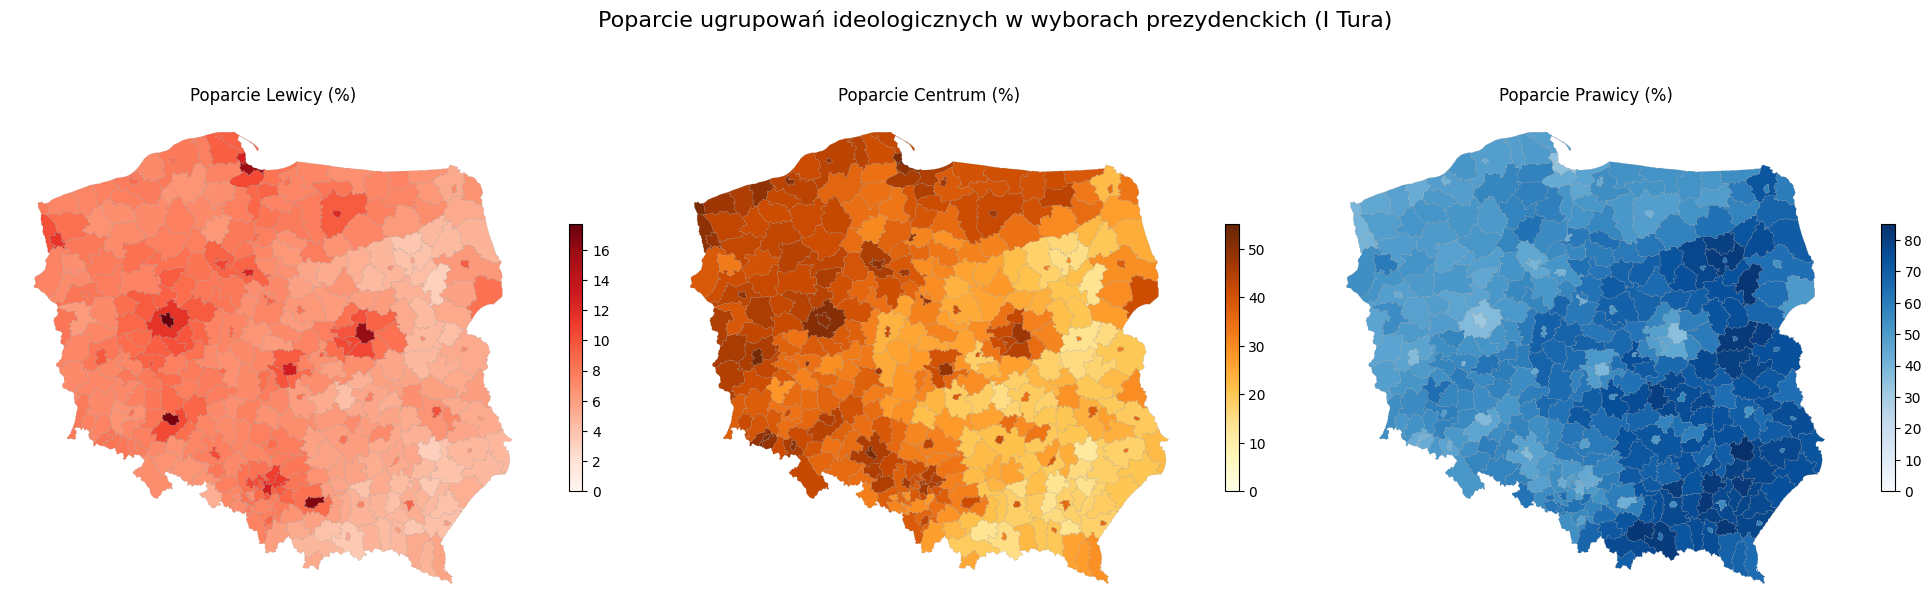

In [28]:
kandydaci_lewica = [
    'BIEJAT Magdalena Agnieszka',
    'ZANDBERG Adrian Tadeusz'
]
kandydaci_centrum = [
    'TRZASKOWSKI Rafał Kazimierz',
    'HOŁOWNIA Szymon Franciszek'
]
kandydaci_prawica = [
    'NAWROCKI Karol Tadeusz',
    'MENTZEN Sławomir Jerzy',
    'BRAUN Grzegorz Michał',
    'STANOWSKI Krzysztof Jakub',
    'JAKUBIAK Marek',
    'BARTOSZEWICZ Artur',
    'SENYSZYN Joanna',
    'WOCH Marek Marian',
    'MACIAK Maciej'
]

lewica_sum = gdf_merged[kandydaci_lewica].sum(axis=1)
centrum_sum = gdf_merged[kandydaci_centrum].sum(axis=1)
prawica_sum = gdf_merged[kandydaci_prawica].sum(axis=1)

all_votes = lewica_sum + centrum_sum + prawica_sum

gdf_merged['Poparcie_Lewica_%'] = lewica_sum/all_votes*100
gdf_merged['Poparcie_Centrum_%'] = centrum_sum/all_votes*100
gdf_merged['Poparcie_Prawica_%'] = prawica_sum/all_votes*100

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Lewica
vmax_lewica = gdf_merged['Poparcie_Lewica_%'].max()
gdf_merged.plot(
    ax=ax1,
    column='Poparcie_Lewica_%',
    cmap='Reds',
    vmin=0,
    vmax=vmax_lewica,
    legend=True,
    legend_kwds={'shrink': 0.5},
    edgecolor='gray',
    linewidth=0.1
)
ax1.axis('off')
ax1.set_title('Poparcie Lewicy (%)')

# Centrum
vmax_centrum = gdf_merged['Poparcie_Centrum_%'].max()
gdf_merged.plot(
    ax=ax2,
    column='Poparcie_Centrum_%',
    cmap='YlOrBr',
    vmin=0,
    vmax=vmax_centrum,
    legend=True,
    legend_kwds={'shrink': 0.5},
    edgecolor='gray',
    linewidth=0.1
)
ax2.axis('off')
ax2.set_title('Poparcie Centrum (%)')

# Prawica
vmax_prawica = gdf_merged['Poparcie_Prawica_%'].max()
gdf_merged.plot(
    ax=ax3,
    column='Poparcie_Prawica_%',
    cmap='Blues',
    vmin=0,
    vmax=vmax_prawica,
    legend=True,
    legend_kwds={'shrink': 0.5},
    edgecolor='gray',
    linewidth=0.1
)
ax3.axis('off')
ax3.set_title('Poparcie Prawicy (%)')

plt.suptitle(
    'Poparcie ugrupowań ideologicznych w wyborach prezydenckich (I Tura)',
    fontsize=16,
    y=1.05
)
plt.tight_layout()
plt.show()


## Zadania dodatkowe dla chętnych: Wizualny Mianownik i Walka z Przestrzenią
---

W tej sekcji przeprowadzimy **radykalną dekonstrukcję** map wyborczych na podstawie wizji W. Rankina.

### Zadanie Dodatkowe A: Problem "Pustych Hektarów" (Visual Denominator)
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 3 "People", s. 134-136).*

Rankin ostro krytykuje standardowe mapy terytorialne, nazywając je "ruralizującymi" (faworyzującymi wieś). Zalesiony powiat na wschodzie w tradycyjnym kartogramie wizualnie "przekrzykuje" Warszawę, chociaż w Warszawie oddano dziesiątki razy więcej głosów.
Zmieńmy **Wizualny Mianownik (Visual Denominator)**. Zamiast kolorować ziemię, narysujmy siłę głosu obywateli.

Stwórz wykres bąbelkowy (punktowy). Użyj `gdf.geometry.centroid`, by znaleźć środki ciężkości powiatów. Narysuj na mapie zarysów dwa nachodzące na siebie "morza" kropek (najpierw niebieskie bąble Prawicy, potem pomarańczowe bąble Centrum). Ich rozmiar (`s=...`) niech odpowiada **ABSOLUTNEJ sumie oddanych głosów** na dany nurt (zsumowane wartości ze zdefiniowanych wcześniej list), a nie procentom. Pamiętaj, aby zmniejszyć kropki proporcjonalnie w Matplotlib, dzieląc zmienną rozmiaru przez np. 500. Zobacz, jak potężne stają się nagle miasta!

### Zadanie Dodatkowe B: Obalenie "Zwycięzca bierze wszystko" (Koniec z Puzzlami)
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 1 "Boundaries", s. 57-60).*

Często widzimy mapy pokazujące po prostu "kto wygrał dany powiat", dzieląc kraj na dwie nienawidzące się połówki. Tworzy to iluzję twardych granic kulturowych.

Mając do dyspozycji wygenerowane wyżej centroidy bąbli, **wyrzuć całkowicie mapę bazową (kontury) pod spodem**. Narysuj kropki "zawieszone w powietrzu".
* Wielkość kropki to całkowita siła zsumowana (wszyscy głosujący w ogóle w powiecie).
* Kolor kropki (przekazywany argumentem `c=`) zależy od tego, czy w danym powiecie zwyciężyło łącznie Centrum czy zsumowana Prawica.
Zauważysz, jak "twarde granice polityczne" Polski ulegają rozmyciu.

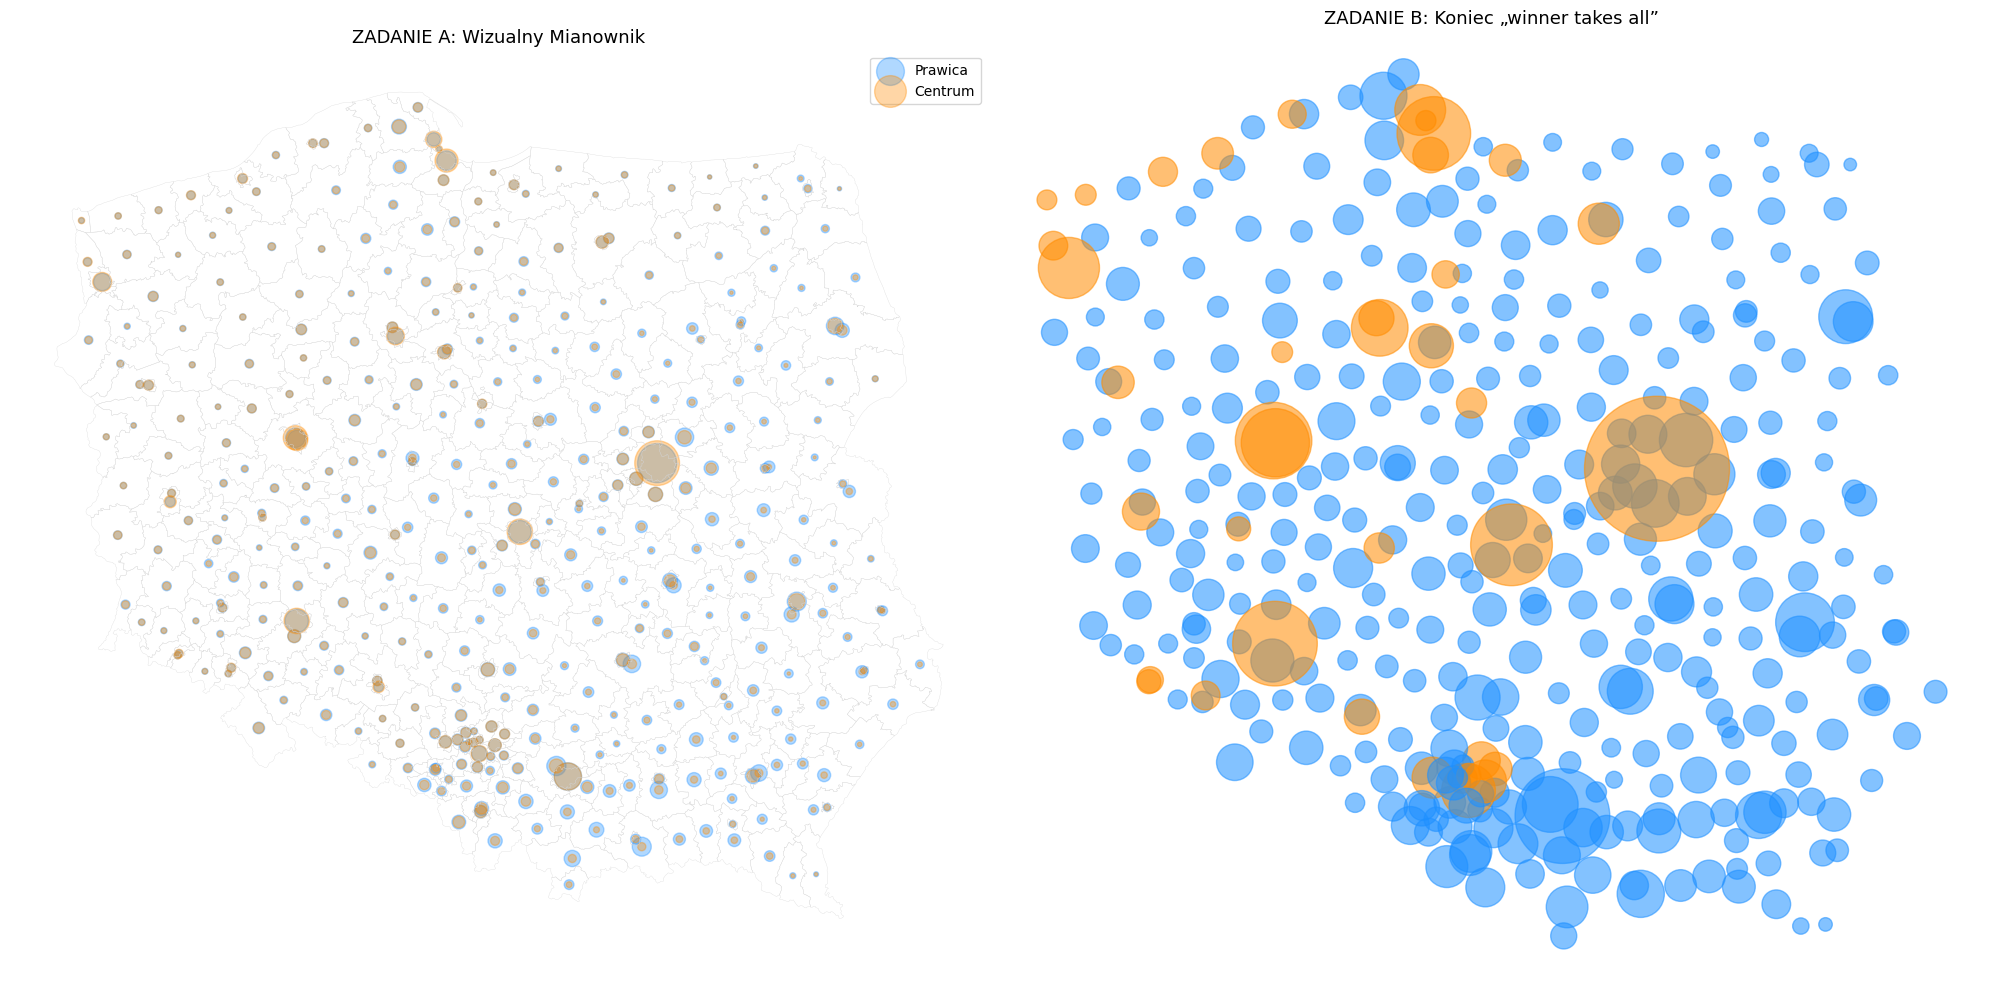

In [30]:
gdf_merged_proj = gdf_merged.to_crs(epsg=2180)
centroids = gdf_merged_proj.geometry.centroid

lewica_sum = gdf_merged[kandydaci_lewica].sum(axis=1)
centrum_sum = gdf_merged[kandydaci_centrum].sum(axis=1)
prawica_sum = gdf_merged[kandydaci_prawica].sum(axis=1)

all_votes = lewica_sum + centrum_sum + prawica_sum

colors = np.where(
    centrum_sum > prawica_sum,
    'darkorange',
    'dodgerblue'
)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]

gdf_merged_proj.boundary.plot(
    ax=ax,
    color='lightgray',
    linewidth=0.2
)

# prawica
ax.scatter(
    centroids.x,
    centroids.y,
    s=prawica_sum / 500,
    color='dodgerblue',
    alpha=0.35,
    label='Prawica'
)

# centrum
ax.scatter(
    centroids.x,
    centroids.y,
    s=centrum_sum / 500,
    color='darkorange',
    alpha=0.35,
    label='Centrum'
)

ax.set_title(
    'ZADANIE A: Wizualny Mianownik',
    fontsize=13
)

ax.legend()
ax.axis('off')

ax = axes[1]
ax.scatter(
    centroids.x,
    centroids.y,
    s=all_votes / 100,
    c=colors,
    alpha=0.55
)

ax.set_title(
    'ZADANIE B: Koniec „winner takes all”',
    fontsize=13
)

ax.axis('off')
plt.tight_layout()
plt.show()